[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlos-argueta/factor-graphs-from-scratch/blob/main/modules/00-ekf-to-least-squares/lesson.ipynb)

# Module 0 — From an EKF to a single least-squares step

> **Goal.** Show that one update of the reference `ExtendedKalmanFilter` (from
> `gaussian_filters/ekf.py`) is exactly **one Gauss–Newton step** on a tiny
> least-squares problem with two factors: a **prior** factor and a **measurement** factor.
> We verify it numerically against the live filter, then re-read it in the **information
> form** — which is exactly the `InformationFilter` (`gaussian_filters/inf.py`) and the native language of
> factor graphs.

This is the conceptual hinge of the whole course:

$$\boxed{\text{a Kalman update} \;=\; \text{a 2-factor factor-graph solve}}$$

Everything later (smoothing, SLAM, calibration) is this same idea with *more factors* and
*more iterations*.

In [2]:
import sys, pathlib, subprocess
import numpy as np

# --- Colab bootstrap -------------------------------------------------------
# On Google Colab the repository isn't present, so clone it once to make the
# course packages (`gaussian_filters`, `fgslam`) importable.
# EDIT REPO_URL to point at your fork.
REPO_URL = "https://github.com/carlos-argueta/factor-graphs-from-scratch.git"
if "google.colab" in sys.modules:
    repo = pathlib.Path("/content/factor-graphs-from-scratch")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo)], check=True)
    if str(repo / "src") not in sys.path:
        sys.path.insert(0, str(repo / "src"))

# --- Local: put the repo's src/ on the path (covers gaussian_filters + fgslam)
def _add_src_to_path():
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "src" / "gaussian_filters").exists():
            if str(base / "src") not in sys.path:
                sys.path.insert(0, str(base / "src"))
            return
_add_src_to_path()

np.set_printoptions(precision=5, suppress=True)

## 1 · Recap: what the EKF `update()` does

From `ekf.py`, the correction step is

```python
H_mu = H(self.mu)
S = H_mu @ self.Sigma @ H_mu.T + Q          # innovation covariance
K = self.Sigma @ H_mu.T @ inv(S)            # Kalman gain
innovation = z - h(self.mu)
self.mu    = self.mu + K @ innovation       # mean update
self.Sigma = (I - K @ H_mu) @ self.Sigma    # covariance update
```

In words: linearise the measurement model $h$ at the prior mean $\bar\mu$, then blend the
prior $(\bar\mu,\bar\Sigma)$ with the measurement $z$ (noise $Q$). Let's pull the *actual*
source into the notebook so there's no hand-waving.

In [3]:
import inspect
from gaussian_filters import ekf
print(inspect.getsource(ekf.ExtendedKalmanFilter.update))

	def update(self, z, dt=None, h=None, H=None, Q=None):
		"""Correct the state with a measurement z.

		Pass h, H and Q to fuse an auxiliary sensor (e.g. GPS) as an
		independent sequential (partitioned) update; omit them to use
		the primary observation model given at construction time.
		"""
		start_time = time.time()

		h = h if h is not None else self.h
		H = H if H is not None else self.H
		Q = Q if Q is not None else self.Q

		# Evaluate the Jacobian once, at the prior mean
		H_mu = H(self.mu)

		# Compute the Kalman gain (K)
		S = H_mu @ self.Sigma @ H_mu.T + Q # Innovation covariance
		K = self.Sigma @ H_mu.T @ np.linalg.inv(S)

		# Update state estimate (mu)
		innovation = z - h(self.mu)
		self.mu = self.mu + (K @ innovation).reshape((self.mu.shape[0],))

		# Update covariance (Sigma)
		I = np.eye(self.mu.shape[0])
		self.Sigma = (I - K @ H_mu) @ self.Sigma

		if self.debug:
			execution_time = time.time() - start_time
			self.exec_times_upd.append(execution_time)
			print(f"Ex

## 2 · The same thing as a least-squares problem (MAP)

The EKF above is a *recipe*: gain, innovation, blend. Our goal in this section is to show
that recipe is secretly **solving an optimisation problem** — "find the state that best
explains prior + measurement." Once we see it that way, adding more sensors or more time
steps is just adding more terms to minimise, which is the whole factor-graph idea.

We'll build it in four small steps: **(2.1)** what we're actually trying to compute (MAP),
**(2.2)** why that turns into a sum of squares, **(2.3)** what "whitened residuals" means,
and **(2.4)** how one **Gauss–Newton** step solves it.

### 2.1 · MAP: the estimate we actually want

We have two sources of information about the state $x$:

- a **prior** — before this measurement we believed $x \sim \mathcal N(\bar\mu, \bar\Sigma)$
  (that's the filter's current $\mu,\Sigma$);
- a **measurement** — we observed $z = h(x) + \nu$ with sensor noise $\nu\sim\mathcal N(0,Q)$.

Bayes' rule combines them into the **posterior** $p(x \mid z) \propto \underbrace{p(z\mid x)}_{\text{likelihood}}\;\underbrace{p(x)}_{\text{prior}}$.
The single "best" state is the one that makes this posterior largest:

$$
x^\star \;=\; \arg\max_x \; p(x\mid z).
$$

This is the **MAP estimate** — *Maximum A Posteriori*, i.e. the peak of the posterior. (If we
had no prior, maximising just the likelihood would be plain Maximum Likelihood; MAP is ML
with a prior pulling on it.) For Gaussians the posterior is itself a bell curve, so its peak
is also its mean — which is why the MAP estimate and the EKF's $\mu$ will come out identical.

### 2.2 · Why maximising the posterior becomes *minimising a sum of squares*

Two standard moves turn the `arg max` into something we can actually solve.

**Move 1 — take the log.** A Gaussian density is an exponential of a quadratic:

$$
p(x) \;\propto\; \exp\!\Big(-\tfrac12\,(x-\bar\mu)^\top \bar\Sigma^{-1}(x-\bar\mu)\Big).
$$

The $\exp$ is monotonic, so whatever maximises $p$ also maximises $\log p$. Taking $\log$
turns the awkward product (prior $\times$ likelihood) into a friendly **sum**, and cancels the
exponential — leaving just the quadratics in the exponent.

**Move 2 — flip the sign.** Maximising $\log p$ is the same as **minimising** $-\log p$.
That's where "negative log-density" comes from: it's just $-\log$ of the posterior, and its
minimum sits exactly at the MAP estimate.

Doing both moves on posterior = prior $\times$ likelihood:

$$
-\log p(x\mid z) \;=\; \underbrace{\tfrac12 (x-\bar\mu)^\top \bar\Sigma^{-1}(x-\bar\mu)}_{\text{from the prior}}
\;+\; \underbrace{\tfrac12 (z-h(x))^\top Q^{-1}(z-h(x))}_{\text{from the measurement}}
\;+\; \text{const}.
$$

The **"up to a constant"** is the normalising factors of the two Gaussians (the
$1/\sqrt{(2\pi)^d\det\Sigma}$ parts). They don't depend on $x$, so they shift the cost up or
down but never move its minimiser — we simply drop them. What's left is a **sum of two
quadratic penalties**, and minimising a sum of quadratics is a **least-squares** problem.
Call that leftover cost $C(x)$:

$$
C(x) \;=\; \tfrac12\,\lVert x-\bar\mu\rVert^2_{\bar\Sigma^{-1}}
\;+\; \tfrac12\,\lVert z-h(x)\rVert^2_{Q^{-1}},
\qquad x^\star = \arg\min_x C(x).
$$

So $C(x)$ isn't an arbitrary definition — each term is literally the negative-log of one
Gaussian. The prior term punishes drifting away from $\bar\mu$; the measurement term punishes
disagreeing with $z$. Each term is one **factor**.

#### The log, worked out (1-D)

Take a scalar Gaussian and apply $\log$ to the whole expression, term by term:

$$
p(x)=\underbrace{\frac{1}{\sigma\sqrt{2\pi}}}_{\text{constant in }x}\;\exp\!\Big(-\frac{(x-\mu)^2}{2\sigma^2}\Big)
$$

$$
\log p(x)=\underbrace{\log\frac{1}{\sigma\sqrt{2\pi}}}_{=\,\text{const}}\;+\;\log\exp\!\Big(-\frac{(x-\mu)^2}{2\sigma^2}\Big)
= \text{const}\;-\;\frac{(x-\mu)^2}{2\sigma^2}
$$

$$
-\log p(x)= \text{const}\;+\;\frac{(x-\mu)^2}{2\sigma^2}.
$$

So the log peels the `exp` off and leaves a **quadratic in $x$**: `log p` is a downward
parabola (peak at $\mu$), `-log p` is an upward parabola (minimum at $\mu$). The constant just
shifts it vertically and never moves the minimiser.

And the reason products turn into sums: for two Gaussians,
$-\log\big(p_1(x)\,p_2(x)\big) = -\log p_1(x) - \log p_2(x)$, i.e. **adding two upward
parabolas** — which gives another upward parabola whose minimum is the precision-weighted
average $\mu^\star = \dfrac{\mu_1/\sigma_1^2 + \mu_2/\sigma_2^2}{1/\sigma_1^2 + 1/\sigma_2^2}$.
That minimum *is* the MAP estimate (prior = $p_1$, likelihood = $p_2$). The plots below show
exactly these shapes.

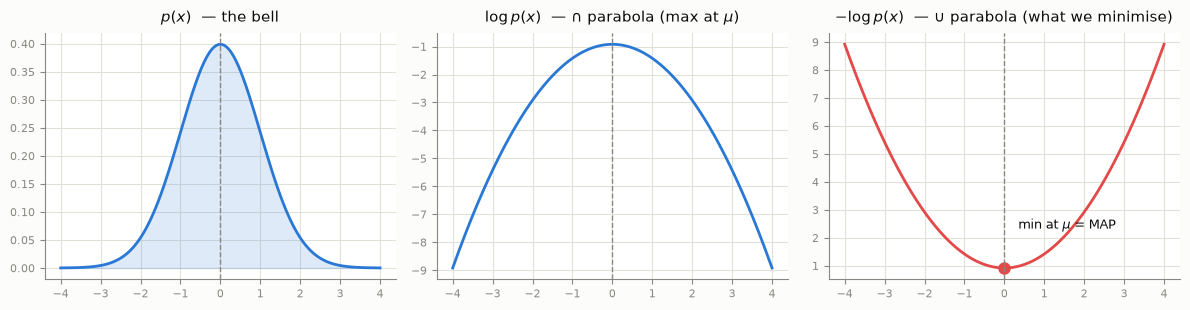

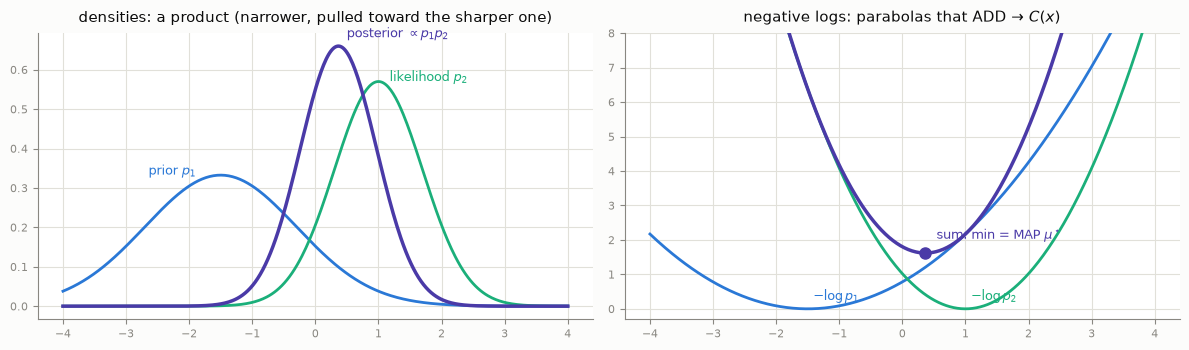

prior mean -1.5, likelihood mean 1.0  ->  MAP mean 0.365  (pulled toward the tighter one)


In [4]:
import matplotlib.pyplot as plt

# palette (light surface) + recessive chrome
BLUE, AQUA, VIOLET, RED = "#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

def _style(ax, title):
    ax.set_title(title, color=INK, fontsize=11, pad=8)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=8)

def gauss(x, mu, sig):
    return np.exp(-((x - mu) ** 2) / (2 * sig ** 2)) / (sig * np.sqrt(2 * np.pi))

# ---- Figure 1: one Gaussian, three views (bell -> parabolas) --------------
mu, sig = 0.0, 1.0
x = np.linspace(-4, 4, 400)
p = gauss(x, mu, sig)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), facecolor="#fcfcfb")
ax[0].fill_between(x, p, color=BLUE, alpha=0.15)
ax[0].plot(x, p, color=BLUE, lw=2)
_style(ax[0], r"$p(x)$  — the bell")
ax[1].plot(x, np.log(p), color=BLUE, lw=2)
_style(ax[1], r"$\log p(x)$  — $\cap$ parabola (max at $\mu$)")
ax[2].plot(x, -np.log(p), color=RED, lw=2)
ax[2].plot(mu, -np.log(gauss(mu, mu, sig)), "o", color=RED, ms=8)
ax[2].annotate("min at $\\mu$ = MAP", (mu, -np.log(gauss(mu, mu, sig))),
               textcoords="offset points", xytext=(10, 28), color=INK, fontsize=9)
_style(ax[2], r"$-\log p(x)$  — $\cup$ parabola (what we minimise)")
for a in ax:
    a.axvline(mu, color=MUTED, ls="--", lw=1)
fig.tight_layout(); plt.show()

# ---- Figure 2: product of Gaussians = sum of parabolas --------------------
mu1, sig1 = -1.5, 1.2      # prior
mu2, sig2 = 1.0, 0.7       # likelihood
prec = 1 / sig1**2 + 1 / sig2**2
mu_post = (mu1 / sig1**2 + mu2 / sig2**2) / prec      # precision-weighted mean
sig_post = np.sqrt(1 / prec)

nll = lambda x, m, s: (x - m) ** 2 / (2 * s ** 2)     # -log density up to a const

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), facecolor="#fcfcfb")
# left: densities (product is peaked between, narrower)
ax[0].plot(x, gauss(x, mu1, sig1), color=BLUE, lw=2)
ax[0].plot(x, gauss(x, mu2, sig2), color=AQUA, lw=2)
ax[0].plot(x, gauss(x, mu_post, sig_post), color=VIOLET, lw=2.5)
ax[0].annotate("prior $p_1$", (mu1, gauss(mu1, mu1, sig1)), color=BLUE, fontsize=9,
               textcoords="offset points", xytext=(-52, 0))
ax[0].annotate("likelihood $p_2$", (mu2, gauss(mu2, mu2, sig2)), color=AQUA, fontsize=9,
               textcoords="offset points", xytext=(8, 0))
ax[0].annotate("posterior $\\propto p_1 p_2$", (mu_post, gauss(mu_post, mu_post, sig_post)),
               color=VIOLET, fontsize=9, textcoords="offset points", xytext=(6, 6))
_style(ax[0], "densities: a product (narrower, pulled toward the sharper one)")
# right: negative-logs add
n1, n2 = nll(x, mu1, sig1), nll(x, mu2, sig2)
ax[1].plot(x, n1, color=BLUE, lw=2)
ax[1].plot(x, n2, color=AQUA, lw=2)
ax[1].plot(x, n1 + n2, color=VIOLET, lw=2.5)
for m, s, c, lab in [(mu1, sig1, BLUE, "$-\\log p_1$"), (mu2, sig2, AQUA, "$-\\log p_2$")]:
    ax[1].annotate(lab, (m, 0), color=c, fontsize=9,
                   textcoords="offset points", xytext=(4, 6))
ax[1].plot(mu_post, nll(mu_post, mu1, sig1) + nll(mu_post, mu2, sig2), "o", color=VIOLET, ms=8)
ax[1].annotate("sum: min = MAP $\\mu^\\star$", (mu_post, nll(mu_post, mu1, sig1) + nll(mu_post, mu2, sig2)),
               color=VIOLET, fontsize=9, textcoords="offset points", xytext=(8, 10))
ax[1].set_ylim(-0.3, 8)
_style(ax[1], "negative logs: parabolas that ADD → $C(x)$")
fig.tight_layout(); plt.show()

print(f"prior mean {mu1}, likelihood mean {mu2}  ->  MAP mean {mu_post:.3f}  (pulled toward the tighter one)")

### 2.3 · Whitened residuals: putting every term on one scale

$C(x)$ from §2.2 is a **sum** of a prior term and a measurement term. Before trusting that sum,
it is worth looking hard at what is being added.

**The problem: the terms don't live on the same scale.** Two separate issues, actually.

1. **Different physical units** *(this bites only when a single sensor reports mixed quantities —
   the range–bearing sensor here is the example; a GPS reporting $(x,y)$ in plain metres wouldn't
   have it).* The residual is a 2-vector,
   $z-h(x)=\big[\ \text{range error (m)},\ \ \text{bearing error (rad)}\ \big]$. *Inside the
   vector* nothing mixes — the metres sit in the range slot, the radians in the bearing slot, and
   metres only ever line up with metres. The clash appears **one step later**. A cost must be a
   single number (a vector can't be minimised), and the only way to turn this residual vector into
   one scalar penalty is to square each component and add:

   $$\lVert z-h(x)\rVert^2 \;=\; \underbrace{(\text{range error})^2}_{\text{metres}^2}\; +\; \underbrace{(\text{bearing error})^2}_{\text{radians}^2}.$$

   *That* addition is the incoherent one — it fuses a metres² quantity and a radians² quantity
   into one number, and the number would change if metres were switched to centimetres even though
   the situation didn't. So the vector is fine; **collapsing it to a scalar with a raw sum of
   squares is what breaks.**
2. **Different confidence.** Even in a single unit, a $0.2\,\text{m}$ error from a $\pm0.1\,\text{m}$
   sensor is a *big deal* (2σ), while the same $0.2\,\text{m}$ from a $\pm2\,\text{m}$ sensor is
   basically noise (0.1σ). A raw sum of squares treats them identically. A correct cost must
   **weight each error by how much that source is trusted.**

**The fix: a plain unweighted $\lVert\cdot\rVert^2$.** Rewrite every term as an ordinary squared
length with *no* weight matrix out front — for two reasons: so the pieces become addable (each
component made dimensionless first, so the squared sum is a coherent single number), and so the
whole thing lands in the exact form a generic least-squares solver expects
($\min \tfrac12\lVert r\rVert^2$). The common unit to standardise to is **"number of standard
deviations."** In σ-units the range and bearing components are directly comparable ("both 2σ
off"), and confidence is already baked in (dividing by a big σ shrinks a noisy sensor's
contribution automatically).

**The Mahalanobis norm is the mechanism that gets us there.** The weight this needs was
*already handed over* by §2.2 — each Gaussian's negative-log came with an inverse-covariance
inside it: $\lVert e\rVert^2_{\Sigma^{-1}} = e^\top\Sigma^{-1}e$. This weighted norm is the
**Mahalanobis norm**, and it is precisely "squared error measured in σ-units." So the weighting
is not *invented* for tidiness — it fell out of the probability. Whitening just **relocates** that
weight from the norm into the residual, leaving a plain norm behind. Factor
$\Sigma^{-1}=(\Sigma^{-1/2})^\top\Sigma^{-1/2}$ (a matrix square root — it exists because a
covariance is symmetric positive-definite; in code we use $\Sigma^{-1/2}=L^{-1}$ from the
Cholesky factor). Then

$$
\lVert e\rVert^2_{\Sigma^{-1}} \;=\; e^\top \Sigma^{-1} e
\;=\; \big(\Sigma^{-1/2} e\big)^\top\big(\Sigma^{-1/2} e\big)
\;=\; \big\lVert \underbrace{\Sigma^{-1/2} e}_{\text{whitened residual}} \big\rVert^2 .
$$

The vector $e_w=\Sigma^{-1/2}e$ is the **whitened residual**: the raw error rescaled so one unit
= one sigma. In this example the range slot is divided by $\sigma_r$ (metres cancel) and the
bearing slot by $\sigma_b$ (radians cancel), so both come out as plain, unitless σ-counts — now
the squared sum in point 1 adds like with like. Geometrically $\Sigma^{-1/2}$ **rotates** to the
covariance's principal axes and **rescales** each axis by $1/\sigma$, turning a tilted, stretched
error ellipse into a unit circle — i.e. into uncorrelated, unit-variance ("*white*") noise. Hence
"whitening." *(The rotate–rescale–rotate-back geometry is worked through in full in
**Appendix A**.)*

**Why "information."** The weight matrix $\Sigma^{-1}$ has a name: the **information matrix**
$\Omega=\Sigma^{-1}$. It appears here for a concrete reason — it *is* the per-term weight, and
weight is exactly "how strongly this source pulls the estimate." Small covariance (confident) ⇒
large $\Omega$ ⇒ steep penalty ⇒ the estimate is dragged hard toward that term; large covariance
(vague) ⇒ small $\Omega$ ⇒ nearly flat penalty ⇒ that term barely matters. So $\Sigma^{-1}$
literally quantifies *how much a Gaussian informs the answer* — which is why the whole additive
picture in §4 is naturally phrased in $\Omega$'s, not $\Sigma$'s.

**Concrete feel.** With $\sigma_r=0.1\,$m and $\sigma_b=0.05\,$rad, a $0.2\,$m range miss whitens
to $0.2/0.1=2$ and a $0.1\,$rad bearing miss whitens to $0.1/0.05=2$: both count as "2σ," now
addable on equal footing regardless of their original units.

**Stack.** Whiten both factors and pile their rows into one residual vector $r(x)$:

$$
r(x)=\begin{bmatrix}\bar\Sigma^{-1/2}\,(x-\bar\mu)\\[4pt] Q^{-1/2}\,(h(x)-z)\end{bmatrix},
\qquad
C(x)=\tfrac12\lVert r(x)\rVert^2 .
$$

The whole MAP problem is now one clean **"minimise half the squared length of $r$"** — no weight
matrices left, every component in σ-units. Each factor simply contributes a block of rows to
$r$; adding a sensor = stacking more rows. That is the shape §2.4 hands to Gauss–Newton.

### 2.4 · One Gauss–Newton step

If $h$ were linear, $C(x)$ would be an exact quadratic (a paraboloid) and its minimum could be
reached in one shot. But $h$ (range–bearing) is **nonlinear**, so $C$ is only *approximately* a
paraboloid. **Gauss–Newton** handles that by repeating a simple loop: *linearise, jump, repeat.*

#### Linearise

The aim is to replace the nonlinear residual $r(x)$, near the current guess $x_0$, by a
straight-line (affine) approximation — because once $r$ is linear in the unknown, $C$ becomes an
*exact* quadratic that can be minimised in closed form.

The tool is the first-order **Taylor expansion** of a vector-valued function. For any smooth
$r:\mathbb R^n\to\mathbb R^m$,

$$
r(x)\;\approx\; r(x_0) + J\,(x-x_0),
\qquad
J \;=\; \frac{\partial r}{\partial x}\Big|_{x_0},
$$

where $J$ is the $m\times n$ **Jacobian** — its entry in row $i$, column $j$ is
$\partial r_i/\partial x_j$ (how residual component $i$ responds to a nudge in state component
$j$). Writing $\delta = x-x_0$ for the step we are solving for and $r_0=r(x_0)$:

$$
r(x)\;\approx\; r_0 + J\,\delta .
$$

Now compute $J$ for our stacked residual, one block at a time. Both blocks have the form
"constant matrix $\times$ (something)", and the whitening matrices $\bar\Sigma^{-1/2}, Q^{-1/2}$
are *constants*, so they pass straight through the derivative.

- **Prior block** $r_p(x)=\bar\Sigma^{-1/2}(x-\bar\mu)$. This is already linear in $x$. The
  derivative of a constant matrix $A$ times $(x-\text{const})$ is just $A$, so

  $$\frac{\partial r_p}{\partial x} = \bar\Sigma^{-1/2}\qquad\text{(exact — the prior factor has no nonlinearity).}$$

- **Measurement block** $r_m(x)=Q^{-1/2}\big(h(x)-z\big)$. The observation $z$ is a constant (its
  derivative is $0$), the whitening $Q^{-1/2}$ is a constant that factors out, and the chain rule
  hits $h$:

  $$\frac{\partial r_m}{\partial x} = Q^{-1/2}\,\frac{\partial h}{\partial x}\Big|_{x_0} = Q^{-1/2} H,
  \qquad H=\frac{\partial h}{\partial x}\Big|_{x_0}$$

  where $H$ is the measurement Jacobian (the range–bearing $H$ built in §3).

Stacking rows in the residual stacks the corresponding block-rows in the Jacobian, so

$$
J=\begin{bmatrix}\bar\Sigma^{-1/2}\\[2pt] Q^{-1/2}H\end{bmatrix}.
$$

Only the measurement block carries any linearisation error; the prior block is exact.

#### Jump

Substitute the linear model $r\approx r_0+J\delta$ into the cost. $C$ is half the squared length
of the residual, so as a function of the step $\delta$,

$$
C(\delta)\;\approx\;\tfrac12\lVert r_0 + J\delta\rVert^2 \;=\; \tfrac12\,(r_0+J\delta)^\top(r_0+J\delta).
$$

Expand the quadratic — using $(r_0+J\delta)^\top(r_0+J\delta)=r_0^\top r_0 + 2\,r_0^\top J\delta + \delta^\top J^\top J\,\delta$
(the cross term is a scalar, so $r_0^\top J\delta=(J^\top r_0)^\top\delta$):

$$
C(\delta)\;\approx\;\underbrace{\tfrac12 r_0^\top r_0}_{\text{const}} \;+\; \underbrace{(J^\top r_0)^\top\delta}_{\text{linear}} \;+\; \underbrace{\tfrac12\,\delta^\top (J^\top J)\,\delta}_{\text{quadratic}} .
$$

This is a plain quadratic in $\delta$ with symmetric matrix $J^\top J$. A quadratic
$\tfrac12\delta^\top A\delta + b^\top\delta + c$ (with $A$ symmetric) has gradient
$\nabla_\delta = A\delta + b$, which vanishes at the minimum. Here $A=J^\top J$ and $b=J^\top r_0$,
so the minimising step solves

$$
\boxed{\;(J^\top J)\,\delta \;=\; -\,J^\top r_0\;}\qquad\text{— the \textbf{normal equations}.}
$$

These are the standard **normal-equations** solution of an overdetermined linear least-squares
system — the general derivation, including its geometric "residual orthogonal to the column space"
meaning, is **Appendix C**. Concretely they are $n$ linear equations in the $n$ unknowns of
$\delta$. Because the prior block $\bar\Sigma^{-1/2}$ is an invertible $n\times n$ matrix, $J$ has
full column rank, which makes $J^\top J$ symmetric **positive-definite** — so the system has a
unique solution

$$
\delta = -\,(J^\top J)^{-1} J^\top r_0,\qquad\text{then}\qquad x \leftarrow x_0 + \delta.
$$

That single linear solve **is one Gauss–Newton step.** ($J^\top J$ is used in place of the true
Hessian of $C$; what that approximation drops, and why it is safe, is **Appendix B**.)

#### Repeat

The linear model $r\approx r_0+J\delta$ is only trustworthy *near* $x_0$: it was built from the
value and slope of $h$ at that one point. Once the step moves the estimate to $x_0+\delta$, both
$h$ and its Jacobian $H$ are different there, so the old linearisation is stale. The fix is to
rebuild it at the new point and step again.

Written as a loop with iteration index $t$, from an initial guess $x_0$:

1. evaluate the residual and Jacobian at the current estimate, $r_t=r(x_t)$ and $J_t=J(x_t)$;
2. solve the normal equations $(J_t^\top J_t)\,\delta_t=-\,J_t^\top r_t$;
3. update $x_{t+1}=x_t+\delta_t$;

stopping when the step $\lVert\delta_t\rVert$ (or the decrease in $C$, or the gradient
$J_t^\top r_t$) drops below a tolerance. Nothing in the machinery changes from one iteration to the
next — only the point at which $r$ and $J$ are evaluated.

Two observations. If $h$ were *linear*, $J$ would be constant, the first step would land exactly on
the minimum, and a second step would return $\delta=0$: the iteration exists purely to chase the
moving linearisation of a *nonlinear* $h$. And near the solution both the residual and the step
shrink, so Gauss–Newton typically converges fast (superlinearly). Module 1's `nls.py` is exactly
this loop, adding Levenberg–Marquardt damping so a step is automatically shortened whenever the
quadratic model overpromises.

#### Specialising to the filter: one step from the prior mean

The Kalman update is the simplest possible instance of this loop — a **single** Gauss–Newton
iteration, taken from the starting point $x_0=\bar\mu$ (the prior mean). Walking the general
formulas through that special case is what produces the closed form.

**The residual at the start.** At $x_0=\bar\mu$ the prior block vanishes,
$\bar\Sigma^{-1/2}(\bar\mu-\bar\mu)=0$, so $r_0$ carries only the measurement mismatch:

$$r_0=\begin{bmatrix}0\\[2pt] Q^{-1/2}\big(h(\bar\mu)-z\big)\end{bmatrix}.$$

Starting exactly at the prior mean is what zeroes the prior's contribution to the *gradient*: the
prior still shapes the Hessian (below), but it pulls nothing until the measurement moves the
estimate off $\bar\mu$.

**The normal-equations matrix.** Multiply out $J^\top J$ with the two stacked blocks. Each block
meets its own transpose and the whitening squares collapse —
$(\bar\Sigma^{-1/2})^\top\bar\Sigma^{-1/2}=\bar\Sigma^{-1}$ and
$(Q^{-1/2}H)^\top(Q^{-1/2}H)=H^\top Q^{-1}H$:

$$
J^\top J=\begin{bmatrix}\bar\Sigma^{-1/2}\\ Q^{-1/2}H\end{bmatrix}^{\!\top}\begin{bmatrix}\bar\Sigma^{-1/2}\\ Q^{-1/2}H\end{bmatrix}=\bar\Sigma^{-1}+H^\top Q^{-1}H .
$$

**The right-hand side.** Only the measurement block of $r_0$ is nonzero, so
$-J^\top r_0$ keeps only that block:

$$
-J^\top r_0=-(Q^{-1/2}H)^\top Q^{-1/2}\big(h(\bar\mu)-z\big)=H^\top Q^{-1}\big(z-h(\bar\mu)\big).
$$

**Solve, and read off the covariance.** The step solves the normal equations, the posterior mean
is $\bar\mu$ plus that step, and the posterior covariance is the inverse of the Hessian:

$$
\delta = \big(\bar\Sigma^{-1}+H^\top Q^{-1}H\big)^{-1} H^\top Q^{-1}\,(z-h(\bar\mu)),
\quad \mu_{\text{post}}=\bar\mu+\delta,
\quad \Sigma_{\text{post}}=\big(\bar\Sigma^{-1}+H^\top Q^{-1}H\big)^{-1}.
$$

**What the formula says, in words.** The Hessian $\bar\Sigma^{-1}+H^\top Q^{-1}H$ is **prior
information plus measurement information** — the additive information-form update that §4 is built
around. The right-hand side $H^\top Q^{-1}(z-h(\bar\mu))$ takes the **innovation** $z-h(\bar\mu)$
(the raw gap between what was observed and what the prior mean predicted — the same quantity §1's
`update()` calls the innovation), weights it by the measurement information $Q^{-1}$, and maps it
into state space with $H^\top$; the inverse Hessian then turns that into the actual step $\delta$.

**Claim:** this $(\mu_{\text{post}},\Sigma_{\text{post}})$ equals the EKF's $(\mu,\Sigma)$ after one
`update()` — even though `ekf.py` writes the correction with a Kalman gain $K=\Sigma H^\top S^{-1}$
rather than an inverted information matrix. The two forms are algebraically identical (related by
the matrix-inversion / Woodbury identity); **Appendix D** proves it line by line. Section 3 also
confirms it numerically against the live filter — first building the whitened stack $r,J$
explicitly (so the $J^\top J$ shortcut isn't a black box), then checking both against the real
`ekf.py`.

## 3 · A concrete example: range–bearing to a known landmark

State is the robot position $x=(p_x,p_y)$. We observe **range** and **bearing** to a known
landmark $L=(\ell_x,\ell_y)$ — a genuinely nonlinear $h$, so the linearisation actually matters.

$$
h(x)=\begin{bmatrix} \sqrt{(\ell_x-p_x)^2+(\ell_y-p_y)^2}\\[2pt] \operatorname{atan2}(\ell_y-p_y,\ \ell_x-p_x)\end{bmatrix}.
$$

In [5]:
# --- problem setup -------------------------------------------------------
L = np.array([5.0, 3.0])                  # landmark
mu0 = np.array([1.0, 1.0])                # prior mean
Sigma0 = np.diag([0.5, 0.8])**2           # prior covariance
sig_r, sig_b = 0.10, 0.05                 # range / bearing std
Q = np.diag([sig_r, sig_b])**2

def h(mu):
    dx, dy = L[0] - mu[0], L[1] - mu[1]
    r = np.hypot(dx, dy)
    return np.array([r, np.arctan2(dy, dx)])

def H(mu):
    dx, dy = L[0] - mu[0], L[1] - mu[1]
    r2 = dx*dx + dy*dy; r = np.sqrt(r2)
    return np.array([[-dx/r,  -dy/r],
                     [ dy/r2, -dx/r2]])

# a measurement: truth slightly off the prior, plus a tiny perturbation
x_true = np.array([1.3, 0.7])
z = h(x_true) + np.array([0.04, -0.02])
z, h(mu0)

(array([4.3966 , 0.53617]), array([4.47214, 0.46365]))

### 3a · Build the whitened residual and Jacobian explicitly

Before the compact normal-equations shortcut, let's construct the actual objects from §2.3–2.4:
whiten each factor, **stack** them into $r_0$ and $J$, and form $J^\top J$. A convenient
whitening matrix is $\Sigma^{-1/2} = L^{-1}$ where $L$ is the Cholesky factor of $\Sigma$
(then $L^{-\top}L^{-1}=\Sigma^{-1}$, exactly the weight we want). We linearise at $x_0=\bar\mu$.

In [6]:
# whitening matrices  Sigma^{-1/2} = inv(chol(Sigma))
Wp = np.linalg.inv(np.linalg.cholesky(Sigma0))   # prior
Wm = np.linalg.inv(np.linalg.cholesky(Q))        # measurement

# stacked whitened residual r0 and Jacobian J at x0 = mu0
r0 = np.concatenate([Wp @ (mu0 - mu0),           # prior block: zero at x0
                     Wm @ (h(mu0) - z)])         # measurement block
J  = np.vstack([Wp,                              # d/dx of (x - mu0) = I, whitened
                Wm @ H(mu0)])                    # whitened measurement Jacobian

JtJ = J.T @ J                                    # Gauss-Newton Hessian
g   = J.T @ r0                                   # gradient  (== J^T r0)
delta   = np.linalg.solve(JtJ, -g)              # one G-N step
mu_stack, Sigma_stack = mu0 + delta, np.linalg.inv(JtJ)

print("stacked r0 =", r0, "   (prior block is 0 because x0 = mu0)")
print("J =\n", J)
print("one G-N step delta =", delta)
print("posterior mean =", mu_stack)
# the compact shortcut J^T J = Sigma^-1 + H^T Q^-1 H is the same matrix:
short = np.linalg.inv(Sigma0) + H(mu0).T @ np.linalg.inv(Q) @ H(mu0)
assert np.allclose(JtJ, short), "stacked J^T J must equal the compact Hessian"
print("J^T J  ==  Sigma^-1 + H^T Q^-1 H   ✓")

stacked r0 = [ 0.       0.       0.75532 -1.45037]    (prior block is 0 because x0 = mu0)
J =
 [[ 2.       0.     ]
 [ 0.       1.25   ]
 [-8.94427 -4.47214]
 [ 2.      -4.     ]]
one G-N step delta = [ 0.19298 -0.22892]
posterior mean = [1.19298 0.77108]
J^T J  ==  Sigma^-1 + H^T Q^-1 H   ✓


### 3b · Run one update of the *real* EKF

We construct the `ExtendedKalmanFilter` with a trivial motion model (we only call `update`)
and our range–bearing observation model, set the prior, and correct once.

In [7]:
from gaussian_filters.ekf import ExtendedKalmanFilter

def motion_model():            # unused here; update() never touches it
    g = lambda mu, u, dt: mu
    G = lambda mu, u, dt: np.eye(2)
    V = None
    return g, G, V

def observation_model():
    return h, H

kf = ExtendedKalmanFilter(
    initial_state=mu0.copy(), initial_covariance=Sigma0.copy(),
    motion_model=motion_model, observation_model=observation_model,
    obs_noise_std=[sig_r, sig_b])

mu_ekf, Sigma_ekf = kf.update(z)
print("EKF posterior mean:", mu_ekf)
print("EKF posterior cov:\n", Sigma_ekf)

EKF posterior mean: [1.19298 0.77108]
EKF posterior cov:
 [[ 0.01646 -0.01403]
 [-0.01403  0.03857]]


### 3c · The same step, compact form

Same Gauss–Newton step as §3a, but instead of stacking $r$ and $J$ we plug straight into the
cancelled-out normal equations $(\bar\Sigma^{-1}+H^\top Q^{-1}H)\,\delta = H^\top Q^{-1}(z-h(\bar\mu))$
and read off mean and the inverse-Hessian covariance. This is the form that matches the EKF
line-for-line.

In [8]:
Omega0 = np.linalg.inv(Sigma0)         # prior information
Qinv   = np.linalg.inv(Q)
Hm     = H(mu0)

Lambda = Omega0 + Hm.T @ Qinv @ Hm     # posterior information (Hessian)
rhs    = Hm.T @ Qinv @ (z - h(mu0))    # -J^T r
delta  = np.linalg.solve(Lambda, rhs)

mu_ls    = mu0 + delta
Sigma_ls = np.linalg.inv(Lambda)
print("LS  posterior mean:", mu_ls)
print("LS  posterior cov:\n", Sigma_ls)

LS  posterior mean: [1.19298 0.77108]
LS  posterior cov:
 [[ 0.01646 -0.01403]
 [-0.01403  0.03857]]


### 3d · They are all the same

EKF `update()`, the compact normal equations, and the explicit whitened stack — one number.

In [9]:
assert np.allclose(mu_ekf, mu_ls, atol=1e-10), "means differ"
assert np.allclose(Sigma_ekf, Sigma_ls, atol=1e-10), "covariances differ"
assert np.allclose(mu_ekf, mu_stack, atol=1e-10), "stacked mean differs"
assert np.allclose(Sigma_ekf, Sigma_stack, atol=1e-10), "stacked cov differs"
print("MATCH — the EKF update IS one Gauss-Newton step on the 2-factor problem.")
print("max |mean diff|  EKF vs compact =", np.max(np.abs(mu_ekf - mu_ls)))
print("max |mean diff|  EKF vs stack   =", np.max(np.abs(mu_ekf - mu_stack)))
print("max |cov  diff|  EKF vs compact =", np.max(np.abs(Sigma_ekf - Sigma_ls)))

MATCH — the EKF update IS one Gauss-Newton step on the 2-factor problem.
max |mean diff|  EKF vs compact = 2.220446049250313e-16
max |mean diff|  EKF vs stack   = 0.0
max |cov  diff|  EKF vs compact = 4.163336342344337e-17


## 4 · The information form — and why it *is* the `InformationFilter`

Look again at the posterior Hessian:

$$
\Lambda_{\text{post}} \;=\; \underbrace{\bar\Sigma^{-1}}_{\text{prior info}} \;+\; \underbrace{H^\top Q^{-1} H}_{\text{measurement info}} .
$$

A measurement **adds information** $H^\top Q^{-1} H$. That is *exactly* the
`InformationFilter.update`, which for a linear read-out $C$ does

```python
self.inf_matrix = self.inf_matrix + C.T @ Q_inv @ C
self.inf_vector = self.inf_vector + C.T @ Q_inv @ z
```

The information matrix **is** the least-squares Hessian $J^\top J$; the information vector is
$-J^\top r$ evaluated at the origin. Factor graphs live in this additive world: **each factor
contributes a block to $\Lambda$ and to the information vector, and you just sum them.** That
additivity is what makes graphs sparse, composable, and incremental — the entire rest of the
course.

In [10]:
# The same two lines live in the reference InformationFilter (gaussian_filters/inf.py).
import inspect
from gaussian_filters import inf
print(inspect.getsource(inf.InformationFilter.update))

	def update(self, z, dt):
		start_time = time.time()
		
		self.inf_matrix = self.inf_matrix + self.C().T @ self.Q_inv @ self.C()
		self.inf_vector = self.inf_vector + self.C().T @ self.Q_inv @ z

		end_time = time.time()
		execution_time = end_time - start_time
		self.exec_times_upd.append(execution_time)
		print(f"Execution time update: {execution_time} seconds")

		print("Average exec time update: ", sum(self.exec_times_upd) / len(self.exec_times_upd))
		
		return self.inf_vector, self.inf_matrix



In [11]:
# Verify the additive information update directly.
Lambda_prior = Omega0
Lambda_meas  = Hm.T @ Qinv @ Hm
assert np.allclose(np.linalg.inv(Sigma_ekf), Lambda_prior + Lambda_meas, atol=1e-10)
print("posterior information = prior information + measurement information  ✓")
print("measurement information added:\n", Lambda_meas)

posterior information = prior information + measurement information  ✓
measurement information added:
 [[84. 32.]
 [32. 36.]]


## 5 · Takeaways

1. **A Kalman update = one Gauss–Newton step** on a 2-factor least-squares problem
   (prior factor + measurement factor). We verified mean *and* covariance against the live
   `ekf.py`.
2. **Covariance form ⇄ information form** are the same object. The information matrix is the
   least-squares Hessian $J^\top J$; a measurement *adds* $H^\top Q^{-1}H$ — the `InformationFilter` (`inf.py`).
3. A **factor graph** is just *many* such factors summed into one big (sparse) information
   matrix, solved by *several* Gauss–Newton steps. The filter is the one-step, two-factor,
   marginalise-as-you-go special case.

**Next (M1):** build the Gauss–Newton / Levenberg–Marquardt engine (`fgslam/nls.py`) that does
the "several iterations over many factors" part — then we start adding factors (M3+).

➡️ See `exercises.ipynb`.

## Appendix

### A · Why $\Sigma^{-1/2}$ turns an error ellipse into a unit circle

§2.3 stated that whitening "rotates to the principal axes and rescales each axis by $1/\sigma$,"
collapsing a tilted, stretched uncertainty ellipse into a unit circle. Here is that geometry in
full.

**An uncertainty ellipse.** A multivariate Gaussian's uncertainty has the shape of an ellipse
(an ellipsoid in higher dimensions), and that shape is fixed entirely by the covariance $\Sigma$.
Correlated errors (say a position error in $x$ tied to the error in $y$) *tilt* the ellipse;
unequal variances *stretch* one axis longer than another. Any covariance factors by its
eigen-decomposition

$$\Sigma = V\,\Lambda\,V^\top,$$

where the **eigenvectors** $V$ point along the ellipse's principal axes — a rotation, i.e. the
tilt — and the **eigenvalues** $\Lambda=\operatorname{diag}(\sigma_1^2,\dots)$ are the variances
along those axes — the stretch.

**The matrix square root carries the same pieces.** The inverse square root factors identically:

$$\Sigma^{-1/2} = V\,\Lambda^{-1/2}\,V^\top.$$

Reading a matrix product right-to-left, forming the whitened residual $e_w=\Sigma^{-1/2}e$ applies
three geometric steps in order:

1. **Rotate to the principal axes — $V^\top$.** Since $V$ encodes the tilt, $V^\top$ un-rotates
   the coordinates so the ellipse's long and short axes line up with the grid.
2. **Rescale each axis — $\Lambda^{-1/2}$.** With the ellipse now square to the axes, each axis is
   multiplied by $1/\sigma$ (the inverse square root of that axis's variance). Every axis is
   scaled by its *own* standard deviation, so all axes reach length exactly $1$: the ellipse
   becomes a unit circle.
3. **Rotate back — $V$.** The final $V$ restores the original orientation. A circle is unchanged
   by rotation, so the result stays an isotropic unit circle.

**What it buys.** Before whitening, an error of $2.0$ along the ellipse's long axis may be routine
while the same $2.0$ along the short axis is a major anomaly — a least-squares solver has no way
to tell which without the metric. After whitening, the tilt and stretch are gone: the whitened
residual is pure, uncorrelated distance in σ-units, where $1.0$ in *any* direction means "one
standard deviation from the mean." That is what lets Gauss–Newton weigh every residual row on
equal terms.

*(When $\Sigma$ is diagonal — as with the range–bearing $Q$ used here — there is no tilt, so
$V=I$ and steps 1 and 3 are the identity; whitening reduces to dividing each component by its own
$\sigma$.)*

### B · Gauss–Newton vs Newton: the term $J^\top J$ leaves out

§2.4 solved $(J^\top J)\,\delta=-J^\top r_0$ and called $J^\top J$ the Hessian. It is only an
*approximation* of the true Hessian of $C$; here is exactly what it drops and why dropping it is
safe.

**The exact derivatives.** Write the cost as a sum over the $m$ residual components, and recall the
Jacobian entry $J_{ij}=\partial r_i/\partial x_j$:

$$
C(x)=\tfrac12\lVert r(x)\rVert^2=\tfrac12\sum_{i=1}^m r_i(x)^2 .
$$

*Gradient — differentiate once.* Take $\partial/\partial x_j$ of $C$, applying the chain rule to each
$r_i^2$ (the $\tfrac12$ cancels the $2$ brought down by the power):

$$
\frac{\partial C}{\partial x_j}
=\tfrac12\sum_i 2\,r_i\,\frac{\partial r_i}{\partial x_j}
=\sum_i r_i\,J_{ij}
=\sum_i J_{ij}\,r_i
=(J^\top r)_j .
$$

The last equality is just the definition of a matrix–vector product with $J^\top$ (whose $(j,i)$
entry is $J_{ij}$). Collecting all components $j$,

$$
\nabla C = J^\top r\qquad(\text{exact — no approximation}).
$$

Because this is exact, the right-hand side $-J^\top r_0$ of the normal equations is exact too; the
approximation, when it comes, is only in the *matrix* on the left.

*Hessian — differentiate again.* Take $\partial/\partial x_k$ of that $j$-th gradient component.
Each summand $r_i\,\partial r_i/\partial x_j$ is a **product** of two $x$-dependent factors, so the
product rule gives two terms:

$$
\frac{\partial^2 C}{\partial x_k\,\partial x_j}
=\sum_i \frac{\partial}{\partial x_k}\!\left(r_i\,\frac{\partial r_i}{\partial x_j}\right)
=\sum_i\Big[\;\underbrace{\frac{\partial r_i}{\partial x_k}\,\frac{\partial r_i}{\partial x_j}}_{\text{two first derivatives}}
\;+\;\underbrace{r_i\,\frac{\partial^2 r_i}{\partial x_k\,\partial x_j}}_{\text{second derivative of }r_i}\;\Big].
$$

The first sum is $\sum_i J_{ik}J_{ij}=(J^\top J)_{kj}$ — the entries of the matrix $J^\top J$. The
second sum weights the Hessian of each scalar residual component,
$(\nabla^2 r_i)_{kj}=\partial^2 r_i/\partial x_k\partial x_j$, by that component's value $r_i$.
Collecting all $k,j$ back into matrices,

$$
\nabla^2 C = \underbrace{J^\top J}_{\text{first-order part}} \;+\; \underbrace{\sum_i r_i\,\nabla^2 r_i}_{\text{second-order part}} .
$$

So the true Hessian has two pieces: $J^\top J$, built only from first derivatives, plus a correction
that couples each residual $r_i$ with the curvature $\nabla^2 r_i$ of the model.

**What Gauss–Newton does.** It keeps $J^\top J$ and drops $\sum_i r_i\,\nabla^2 r_i$. The full
Newton method would keep both. In our stacked residual the prior rows are linear, so their
$\nabla^2 r_i=0$ and they contribute nothing to the dropped term; the entire correction comes
from the **second derivatives of $h$** in the measurement rows.

**Why the approximation is safe — and cheap.**

- **Small near the solution.** The dropped term is proportional to the residuals $r_i$. For a
  model that fits well, the whitened residuals are small (a few σ at most), so $\sum_i r_i\nabla^2 r_i$
  is small next to $J^\top J$ and vanishes as the fit improves.
- **Always a descent direction.** $J^\top J$ is positive-(semi)definite by construction, so the
  step it produces always points downhill. The true Hessian can be indefinite far from the
  optimum, where a raw Newton step may head the wrong way.
- **No second derivatives.** Only $J$ (first derivatives of $h$) is ever needed — never
  $\nabla^2 h$ — which is what makes each step cheap.

**The price.** For strongly nonlinear, large-residual problems the neglected curvature matters,
and plain Gauss–Newton can overshoot or diverge. The standard fix is **Levenberg–Marquardt**:
solve $(J^\top J+\lambda\,\mathrm{diag}(J^\top J))\,\delta=-J^\top r$, interpolating between a
Gauss–Newton step ($\lambda\to0$) and a short, safe gradient-descent step ($\lambda$ large), with
$\lambda$ adapted each iteration. That is the engine built in Module 1.

**Tie-back to the filter.** The EKF linearises $h$ once, at the prior mean, and takes a single
step — precisely *one* Gauss–Newton iteration from $x_0=\bar\mu$. So the EKF inherits exactly
this approximation: it too drops $\sum_i r_i\nabla^2 r_i$, which is why an EKF update is only
statistically exact when $h$ is linear or the residuals are small.

### C · The normal equations for a linear least-squares system (refresher)

§2.4 reached $(J^\top J)\,\delta=-J^\top r_0$ by expanding a quadratic. That result is one instance
of a standard fact about **overdetermined linear systems**. This appendix derives it in general —
twice, by calculus and by geometry — and then maps it back to the Gauss–Newton step.

**The setup.** Consider a linear system

$$
A\,x \;\approx\; b,\qquad A\in\mathbb R^{m\times n},\ \ m>n,
$$

with more equations ($m$) than unknowns ($n$) — the usual situation once several factors constrain
the same state. In general *no* $x$ satisfies all $m$ equations at once (the equations disagree),
so exact solving is off the table. Instead pick the $x$ that misses by the least total squared
amount:

$$
x^\star=\arg\min_x f(x),\qquad f(x)=\lVert Ax-b\rVert^2 .
$$

**Derivation 1 — calculus.** Expand the objective (a scalar; each cross term equals its own
transpose, so $x^\top A^\top b = b^\top A x$):

$$
f(x)=(Ax-b)^\top(Ax-b)=x^\top A^\top A\,x \;-\; 2\,b^\top A\,x \;+\; b^\top b .
$$

This is a quadratic in $x$; its gradient is $\nabla f = 2A^\top A\,x - 2A^\top b$. Setting
$\nabla f = 0$ gives the **normal equations**

$$
\boxed{\;A^\top A\,x \;=\; A^\top b\;}
$$

and, when $A$ has full column rank (so $A^\top A$ is invertible and positive-definite),

$$
x^\star = (A^\top A)^{-1}A^\top b .
$$

**Derivation 2 — geometry (why "normal").** As $x$ ranges over $\mathbb R^n$, the product $Ax$
sweeps out the **column space** of $A$ — the subspace spanned by $A$'s columns. The vector $b$
generally lies *off* that subspace, so $Ax$ can never equal it; the best reachable $Ax$ is the
**orthogonal projection** of $b$ onto the column space, the closest point in the subspace. "Closest"
means the leftover residual $b-Ax^\star$ is **perpendicular** to the subspace — orthogonal to every
column of $A$:

$$
A^\top\,(b - Ax^\star)=0 \quad\Longleftrightarrow\quad A^\top A\,x^\star = A^\top b .
$$

The same equations fall out. The name *normal* equations comes from exactly this: the optimal
residual is **normal** (orthogonal) to the column space of $A$.

**Back to Gauss–Newton.** §2.4 minimises $\tfrac12\lVert r_0 + J\delta\rVert^2$ over the step
$\delta$. Write it as the standard form above with

$$
A = J,\qquad x = \delta,\qquad b = -\,r_0 ,
$$

(minimising $\lVert J\delta-(-r_0)\rVert^2$ is minimising $\lVert r_0+J\delta\rVert^2$; the factor
$\tfrac12$ doesn't move the minimiser). Substituting into $A^\top A\,x=A^\top b$ gives

$$
J^\top J\,\delta = J^\top(-r_0) = -\,J^\top r_0 ,
$$

precisely the boxed normal equations of §2.4. So a Gauss–Newton step is nothing more than the
linear least-squares solution of the *linearised* residual — and by the geometry above, it makes
the linearised residual orthogonal to the column space of $J$.

### D · Proof: the information-form update equals the Kalman-gain update

§2.4 claimed the one-step Gauss–Newton result equals the EKF's `update()`, even though the two are
written differently — one inverts an information matrix, the other multiplies by a Kalman gain.
Here is the algebra that makes them the same object, using the **Woodbury matrix identity**.

**The two forms.** Write the innovation $\nu = z-h(\bar\mu)$. Section 2.4 produced the
**information form**

$$
\Lambda = \bar\Sigma^{-1}+H^\top Q^{-1}H,\qquad
\Sigma_{\text{post}}=\Lambda^{-1},\qquad
\mu_{\text{post}}=\bar\mu+\Lambda^{-1}H^\top Q^{-1}\nu ,
$$

while `ekf.py` (§1) uses the **gain form**, with innovation covariance $S=H\bar\Sigma H^\top+Q$ and
Kalman gain $K=\bar\Sigma H^\top S^{-1}$,

$$
\Sigma_{\text{post}}^{\text{EKF}}=(I-KH)\bar\Sigma,\qquad
\mu_{\text{post}}^{\text{EKF}}=\bar\mu+K\nu .
$$

Take $\bar\Sigma$ and $Q$ symmetric positive-definite, so every inverse below exists. Two things
must be shown: $\Lambda^{-1}=(I-KH)\bar\Sigma$ (the covariances match) and
$\Lambda^{-1}H^\top Q^{-1}=K$ (so the mean corrections match).

**Step 1 — covariance, via Woodbury.** The Woodbury identity is

$$
(A+UCV)^{-1}=A^{-1}-A^{-1}U\,(C^{-1}+VA^{-1}U)^{-1}\,VA^{-1}.
$$

Apply it to $\Lambda=\bar\Sigma^{-1}+H^\top Q^{-1}H$ with $A=\bar\Sigma^{-1}$, $U=H^\top$,
$C=Q^{-1}$, $V=H$. Then $A^{-1}=\bar\Sigma$, $C^{-1}=Q$, $VA^{-1}U=H\bar\Sigma H^\top$, and the
inner factor is $C^{-1}+VA^{-1}U=Q+H\bar\Sigma H^\top=S$. So

$$
\Lambda^{-1}=\bar\Sigma-\bar\Sigma H^\top S^{-1}H\bar\Sigma
=\bar\Sigma-\big(\bar\Sigma H^\top S^{-1}\big)H\bar\Sigma
=(I-KH)\bar\Sigma ,
$$

recognising $K=\bar\Sigma H^\top S^{-1}$. Hence $\Sigma_{\text{post}}=\Sigma_{\text{post}}^{\text{EKF}}$.
$\qquad\blacksquare$ *(covariance)*

**Step 2 — gain, hence mean.** It remains to show the information-form gain
$\Lambda^{-1}H^\top Q^{-1}$ equals $K$. Start from Step 1's $\Lambda^{-1}=(I-KH)\bar\Sigma$ and
expand:

$$
\Lambda^{-1}H^\top Q^{-1}=(I-KH)\bar\Sigma H^\top Q^{-1}
=\bar\Sigma H^\top Q^{-1}-K\,\big(H\bar\Sigma H^\top\big)\,Q^{-1}.
$$

Use $H\bar\Sigma H^\top=S-Q$ and $KS=\bar\Sigma H^\top S^{-1}S=\bar\Sigma H^\top$ to simplify the
second term:

$$
K\,\big(H\bar\Sigma H^\top\big)\,Q^{-1}=K(S-Q)Q^{-1}=KSQ^{-1}-K=\bar\Sigma H^\top Q^{-1}-K.
$$

Substituting back, the $\bar\Sigma H^\top Q^{-1}$ pieces cancel:

$$
\Lambda^{-1}H^\top Q^{-1}=\bar\Sigma H^\top Q^{-1}-\big(\bar\Sigma H^\top Q^{-1}-K\big)=K.
$$

Therefore
$\mu_{\text{post}}=\bar\mu+\Lambda^{-1}H^\top Q^{-1}\nu=\bar\mu+K\nu=\mu_{\text{post}}^{\text{EKF}}$.
$\qquad\blacksquare$ *(mean)*

**Conclusion.** Both the mean and the covariance of the one-step Gauss–Newton update coincide with
the EKF's `update()` output, for any measurement Jacobian $H$ and any positive-definite
$\bar\Sigma$, $Q$. §3 checks the very same statement numerically on the range–bearing example, where
the difference sits at the level of floating-point round-off.